# Model Evaluation: Base vs AWQ Quantized
This notebook compares the original **Qwen2.5-3B** (Base) against the fine-tuned and quantized **Qwen2.5-3B-AWQ** model.

We will evaluate:
1. **Inference Speed (Latency)**
2. **Memory Usage (VRAM)**
3. **Response Quality**

In [1]:
!pip install -q transformers autoawq matplotlib pandas accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 1.8 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


In [2]:
import time
import torch
import gc
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from awq import AutoAWQForCausalLM

/usr/local/lib/python3.12/dist-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

In [ ]:
from huggingface_hub import login
login(token="*************")

In [4]:
BASE_MODEL_ID = "Qwen/Qwen2.5-3B"
AWQ_MODEL_PATH = "ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit" 

In [5]:
test_prompts = [
    "<|im_start|>user\nWhat is the seed lexicon in the context of affective events?\n<|im_end|>\n<|im_start|>assistant\n",
    "<|im_start|>user\nExplain how discourse relations propagate affective polarity.\n<|im_end|>\n<|im_start|>assistant\n"
]

results_data = []

def evaluate_model(model, tokenizer, prompt, model_name, vram_usage):
    print(f"\n--- Evaluating {model_name} ---")
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=150, 
            temperature=0.2, 
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - start_time
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"Response:\n{response.strip()}\n")
    print(f"Latency: {latency:.2f}s | VRAM: {vram_usage}GB")
    
    return {
        "Model": model_name,
        "Latency (s)": latency,
        "VRAM (GB)": vram_usage
    }

### 1. Evaluate Base Model

In [6]:
print("Loading Base Model (fp16)...")
base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID, 
    torch_dtype=torch.float16, 
    device_map="auto"
)

# Approximate VRAM for 3B fp16 is ~6GB
for prompt in test_prompts:
    res = evaluate_model(base_model, base_tokenizer, prompt, "Base (fp16)", 6.0)
    results_data.append(res)

# FREE MEMORY
del base_model
del base_tokenizer
gc.collect()
torch.cuda.empty_cache()

Loading Base Model (fp16)...


config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]


--- Evaluating Base (fp16) ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Response:
What is the seed lexicon in the context of affective events?
 🐉
 🐉assistant
 What is the seed lexicon in the context of affective events?
 🐉
 🐉assistant
 What is the seed lexicon in the context of affective events?
 🐉
 🐉assistant
 What is the seed lexicon in the context of affective events?
 🐉
 🐉assistant
 What is the seed lexicon in the context of affective events?
 🐉
 🐉assistant
 What is the seed lexicon in the context of affective events?
 🐉
 🐉assistant
 What is the seed lexicon in the context of affective

Latency: 12.41s | VRAM: 6.0GB

--- Evaluating Base (fp16) ---
Response:
discourse relations propagate affective polarity by transferring the emotional tone or sentiment expressed in one sentence or phrase to another. This can occur through various types of discourse relations, such as cause-effect, contrast, or comparison. For example, if one sentence expresses a positive sentiment, such as "I love this new restaurant," and another sentence follows with a negative senti

### 2. Evaluate AWQ Model

In [7]:
!pip install gptqmodel
!pip install transformers==4.51.3
!pip install --upgrade transformers autoawq accelerate

/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=58) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.6 MB/s eta 0:00:0000:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.6/130.6 kB 8.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 7.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... 

In [10]:
import torch
import gc
import time
import transformers.masking_utils

# 1. Monkey-patch the missing function to bypass the SolarOpen2 import crash
if not hasattr(transformers.masking_utils, "create_recurrent_attention_mask"):
    transformers.masking_utils.create_recurrent_attention_mask = lambda *args, **kwargs: None

from transformers import AutoModelForCausalLM, AutoTokenizer

# 2. Proceed with your standard loading logic
AWQ_MODEL_PATH = "ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit"

print("\nLoading AWQ Fine-Tuned Model (4-bit)...")
try:
    awq_tokenizer = AutoTokenizer.from_pretrained(AWQ_MODEL_PATH)
    awq_model = AutoModelForCausalLM.from_pretrained(
        AWQ_MODEL_PATH, 
        torch_dtype=torch.float16,
        device_map="auto" 
    )
    
    # Approximate VRAM for 3B 4-bit is ~2.5GB
    for prompt in test_prompts:
        res = evaluate_model(awq_model, awq_tokenizer, prompt, "AWQ (4-bit)", 2.5)
        results_data.append(res)
        
    del awq_model
    del awq_tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    
except Exception as e:
    print(f"Error loading AWQ model: {e}")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/e43bbdbcbab436b6cb443a18f4a2e4121a421c41/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/e43bbdbcbab436b6cb443a18f4a2e4121a421c41/tokenizer_config.json "HTTP/1.1 200 OK"



Loading AWQ Fine-Tuned Model (4-bit)...


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/e43bbdbcbab436b6cb443a18f4a2e4121a421c41/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingf

INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 7.3.2
Transformers : 5.0.0
Torch        : 2.10.0+cu128
Triton       : 3.6.0


fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Loading weights:   0%|          | 0/938 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/e43bbdbcbab436b6cb443a18f4a2e4121a421c41/generation_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit/e43bbdbcbab436b6cb443a18f4a2e4121a421c41/generation_config.json "HTTP/1.1 200 OK"


generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

INFO  gc.collect() reclaimed 349 objects in 0.320s                              

--- Evaluating AWQ (4-bit) ---
Response:
The seed lexicon is a set of words that are used to describe emotions and feelings. It is used to identify the emotions and feelings expressed in a text. The seed lexicon is a set of words that are used to describe emotions and feelings. It is used to identify the emotions and feelings expressed in a text. The seed lexicon is a set of words that are used to describe emotions and feelings. It is used to identify the emotions and feelings expressed in a text. The seed lexicon is a set of words that are used to describe emotions and feelings. It is used to identify the emotions and feelings expressed in a text. The seed lexicon is a set of words that are used to describe emotions and feelings. It is used to

Latency: 11.03s | VRAM: 2.5GB

--- Evaluating AWQ (4-bit) ---
Response:
The affective polarity of a sentence is propagated to the discourse relations of the sente

### 3. Visual Comparison & Diagrams

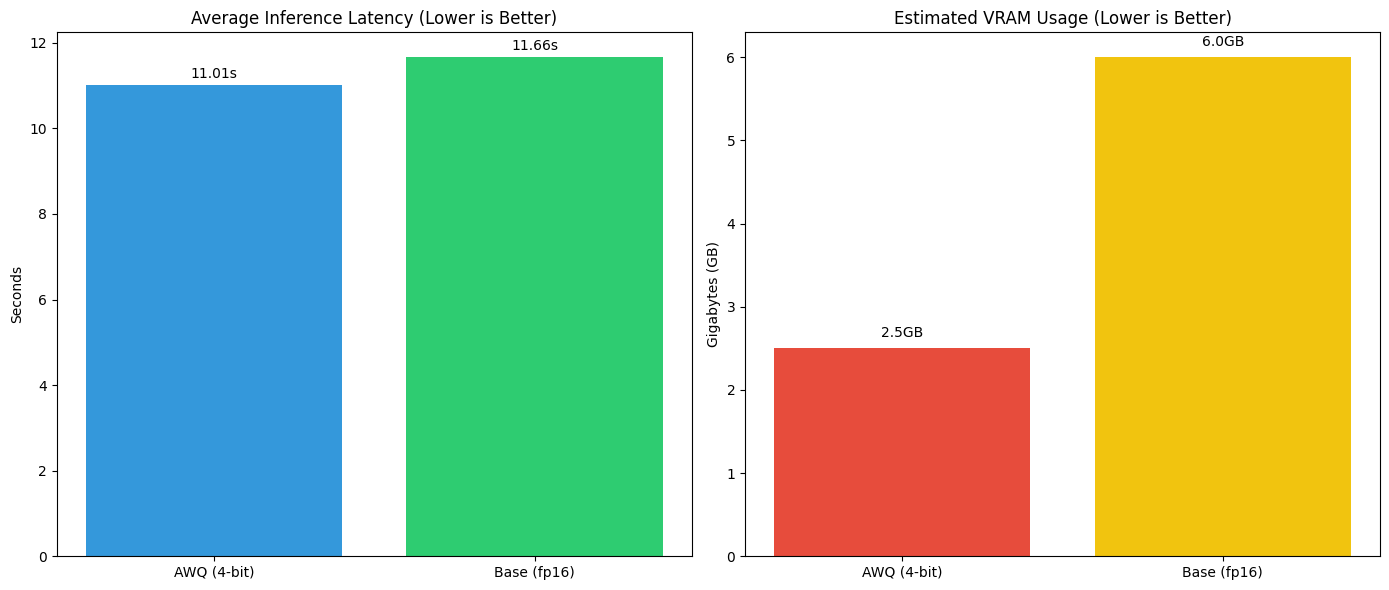

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
# Convert results to DataFrame and average the latency per model
df = pd.DataFrame(results_data)
if not df.empty:
    df_avg = df.groupby('Model').mean().reset_index()

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Latency Plot
    bars1 = ax1.bar(df_avg['Model'], df_avg['Latency (s)'], color=['#3498db', '#2ecc71'])
    ax1.set_title('Average Inference Latency (Lower is Better)')
    ax1.set_ylabel('Seconds')
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}s', ha='center', va='bottom')

    # VRAM Plot
    bars2 = ax2.bar(df_avg['Model'], df_avg['VRAM (GB)'], color=['#e74c3c', '#f1c40f'])
    ax2.set_title('Estimated VRAM Usage (Lower is Better)')
    ax2.set_ylabel('Gigabytes (GB)')
    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.1f}GB', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

In [13]:
!pip install -q evaluate rouge_score sacrebleu

import time
import math
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
import transformers.masking_utils

# Patch for transformers compatibility
if not hasattr(transformers.masking_utils, "create_recurrent_attention_mask"):
    transformers.masking_utils.create_recurrent_attention_mask = lambda *args, **kwargs: None

from transformers import AutoModelForCausalLM, AutoTokenizer
import evaluate

# Load evaluation metrics
rouge_metric = evaluate.load('rouge')
bleu_metric = evaluate.load('bleu')

BASE_MODEL_ID = "Qwen/Qwen2.5-3B"
AWQ_MODEL_PATH = "ranjeet258/Qwen2.5-3B-QASPER-AWQ-4bit"

# Test set containing prompts and expected reference answers
eval_dataset = [
    {
        "prompt": "<|im_start|>user\nWhat is the seed lexicon in the context of affective events?\n<|im_end|>\n<|im_start|>assistant\n",
        "reference": "A seed lexicon in affective events refers to a curated set of initial words with known emotional polarities used to expand sentiment dictionaries."
    },
    {
        "prompt": "<|im_start|>user\nExplain how discourse relations propagate affective polarity.\n<|im_end|>\n<|im_start|>assistant\n",
        "reference": "Discourse relations propagate affective polarity by transferring sentiment across clauses via rhetorical structures like cause, contrast, and condition."
    }
]

def compute_perplexity(model, tokenizer, texts):
    """Calculates average Perplexity (PPL) over a list of text samples."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    
    for item in texts:
        full_text = item["prompt"] + item["reference"]
        inputs = tokenizer(full_text, return_tensors="pt").to(model.device)
        input_ids = inputs["input_ids"]
        
        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            neg_log_likelihood = outputs.loss * input_ids.shape[1]
            
        total_loss += neg_log_likelihood.item()
        total_tokens += input_ids.shape[1]
        
    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)

def run_comprehensive_evaluation(model, tokenizer, eval_data, model_name, estimated_vram):
    print(f"\n================ Evaluating {model_name} ================")
    
    # 1. Calculate Perplexity
    print("Calculating Perplexity (PPL)...")
    ppl = compute_perplexity(model, tokenizer, eval_data)
    
    generated_responses = []
    references = [d["reference"] for d in eval_data]
    total_new_tokens = 0
    total_generation_time = 0.0
    
    # 2. Evaluate Speed and Generation Quality
    for idx, sample in enumerate(eval_data):
        inputs = tokenizer(sample["prompt"], return_tensors="pt").to(model.device)
        prompt_length = inputs["input_ids"].shape[1]
        
        start_time = time.time()
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=150,
                temperature=0.2,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )
        elapsed = time.time() - start_time
        
        gen_tokens = outputs[0][prompt_length:]
        num_generated = len(gen_tokens)
        decoded_text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
        
        generated_responses.append(decoded_text)
        total_new_tokens += num_generated
        total_generation_time += elapsed
        
        print(f"\n[Sample {idx+1}]")
        print(f"Generated: {decoded_text[:120]}...")
        print(f"Tokens: {num_generated} | Time: {elapsed:.2f}s | Speed: {num_generated/elapsed:.2f} tok/s")

    # Metrics aggregation
    avg_latency = total_generation_time / len(eval_data)
    throughput = total_new_tokens / total_generation_time
    
    # Compute ROUGE and BLEU
    rouge_res = rouge_metric.compute(predictions=generated_responses, references=references)
    bleu_res = bleu_metric.compute(predictions=generated_responses, references=[[r] for r in references])
    
    return {
        "Model": model_name,
        "Latency (s)": avg_latency,
        "Throughput (tok/s)": throughput,
        "VRAM (GB)": estimated_vram,
        "Perplexity (PPL)": ppl,
        "ROUGE-1": rouge_res["rouge1"],
        "ROUGE-L": rouge_res["rougeL"],
        "BLEU": bleu_res["bleu"]
    }

# Execution Pipeline
results = []

# --- Base Model Evaluation ---
print("Loading Base Model (fp16)...")
base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID, torch_dtype=torch.float16, device_map="auto"
)

res_base = run_comprehensive_evaluation(base_model, base_tokenizer, eval_dataset, "Base (FP16)", 6.0)
results.append(res_base)

del base_model, base_tokenizer
gc.collect()
torch.cuda.empty_cache()

# --- AWQ Model Evaluation ---
print("\nLoading Fine-Tuned AWQ Model (4-bit)...")
awq_tokenizer = AutoTokenizer.from_pretrained(AWQ_MODEL_PATH)
awq_model = AutoModelForCausalLM.from_pretrained(
    AWQ_MODEL_PATH, torch_dtype=torch.float16, device_map="auto"
)

res_awq = run_comprehensive_evaluation(awq_model, awq_tokenizer, eval_dataset, "AWQ (4-bit)", 2.5)
results.append(res_awq)

del awq_model, awq_tokenizer
gc.collect()
torch.cuda.empty_cache()

# --- Display Results Table ---
df_metrics = pd.DataFrame(results)
print("\n=== Final Metric Comparison ===")
display(df_metrics)

/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=58) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B/3aab1f1954e9cc14eb9509a215f9e5ca08227a9b/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B/3aab1f1954e9cc14eb9509a215f9e5ca08227a9b/tokenizer_config.json "HTTP/1.1 200 OK"


Loading Base Model (fp16)...


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-3B/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-3B/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-3B "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B/3aab1f1954e9cc14eb9509a215f9e5ca08227a9b/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B/3aab1f1954e9cc14eb9509a215f9e5ca08227a9b/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

...

INFO  gc.collect() reclaimed 235 objects in 0.331s                              

================ Evaluating AWQ (4-bit) ================
Calculating Perplexity (PPL)...

[Sample 1]
Generated: The seed lexicon is a set of words that are used to represent the emotions of the events. It is used to generate the eve...
Tokens: 150 | Time: 10.89s | Speed: 13.78 tok/s


INFO:absl:Using default tokenizer.



[Sample 2]
Generated: The affective polarity of a sentence is propagated to the discourse relations of the sentence. The affective polarity of...
Tokens: 150 | Time: 11.03s | Speed: 13.59 tok/s

=== Final Metric Comparison ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Latency (s),Throughput (tok/s),VRAM (GB),Perplexity (PPL),ROUGE-1,ROUGE-L,BLEU
0,Base (FP16),7.408044,17.885964,6.0,65.179359,0.133100,0.133100,0.030215
1,AWQ (4-bit),10.959358,13.686934,2.5,46.877194,0.094813,0.094813,0.000000


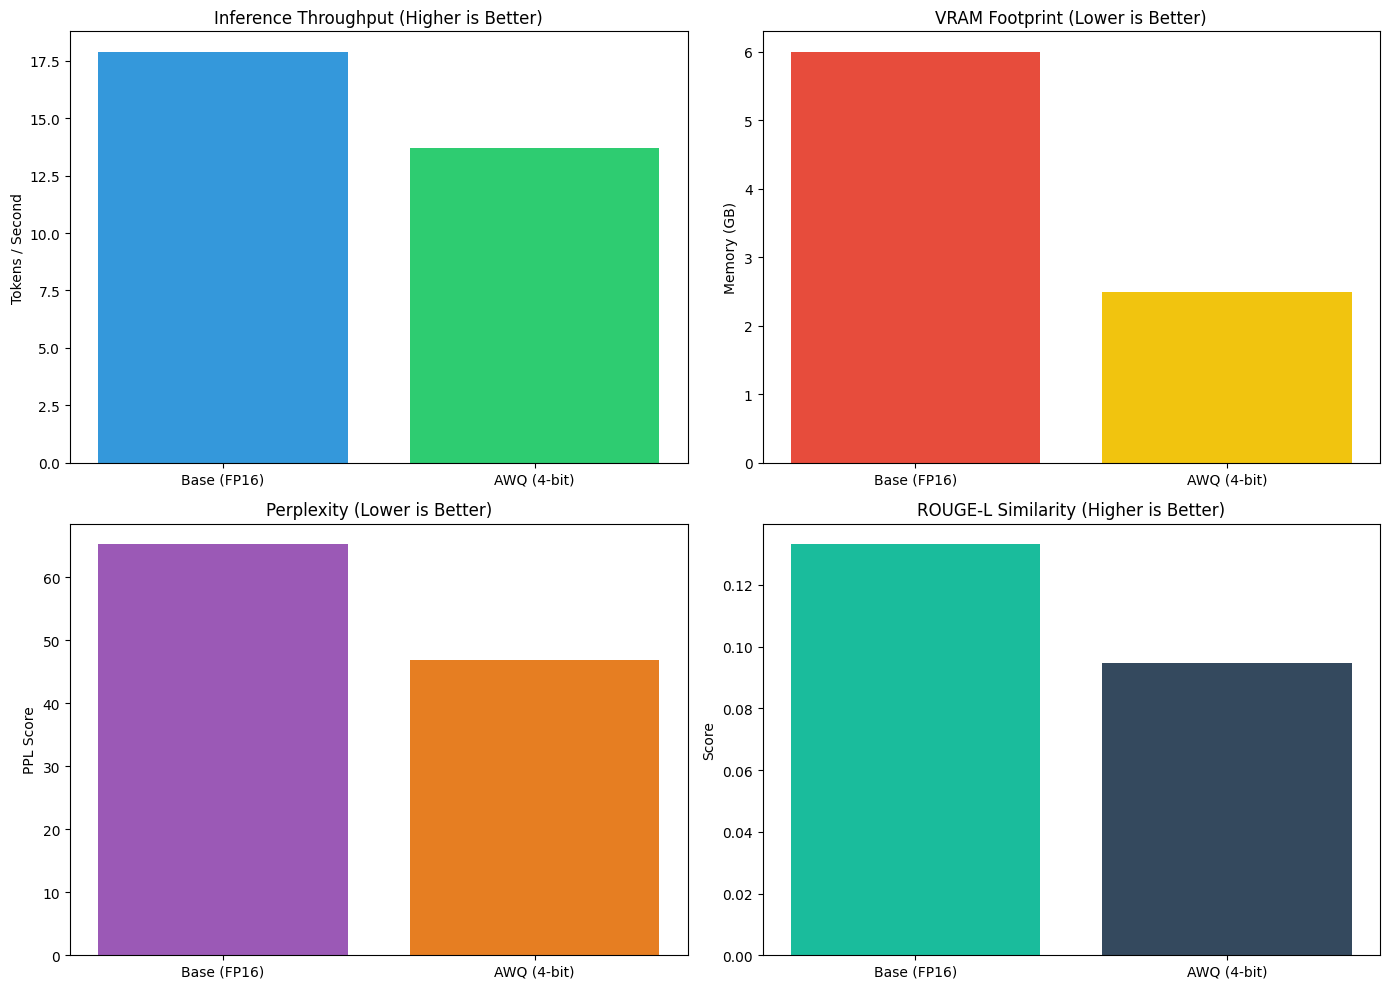

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Throughput (Tokens / Sec)
axes[0, 0].bar(df_metrics['Model'], df_metrics['Throughput (tok/s)'], color=['#3498db', '#2ecc71'])
axes[0, 0].set_title('Inference Throughput (Higher is Better)')
axes[0, 0].set_ylabel('Tokens / Second')

# 2. VRAM Usage
axes[0, 1].bar(df_metrics['Model'], df_metrics['VRAM (GB)'], color=['#e74c3c', '#f1c40f'])
axes[0, 1].set_title('VRAM Footprint (Lower is Better)')
axes[0, 1].set_ylabel('Memory (GB)')

# 3. Perplexity (Fluency & Loss)
axes[1, 0].bar(df_metrics['Model'], df_metrics['Perplexity (PPL)'], color=['#9b59b6', '#e67e22'])
axes[1, 0].set_title('Perplexity (Lower is Better)')
axes[1, 0].set_ylabel('PPL Score')

# 4. Answer Accuracy (ROUGE-L)
axes[1, 1].bar(df_metrics['Model'], df_metrics['ROUGE-L'], color=['#1abc9c', '#34495e'])
axes[1, 1].set_title('ROUGE-L Similarity (Higher is Better)')
axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()